# Route-3 2,048-Point Cortex-Rate Simulation Bank

This notebook audits the authorized, resumable 2,048-row bank for the frozen
synthetic cortical-rate 14D schema. It does not train a posterior. Each theta
uses a distinct, deterministic simulator seed; all failures remain in the
manifest. Scaling is fit only on the fixed training split.

In [1]:
from __future__ import annotations
from datetime import datetime, timezone
import json
import os
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import nbformat
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "S4_sbi" / "src").exists():
    for parent in PROJECT_ROOT.parents:
        if (parent / "S4_sbi" / "src").exists():
            PROJECT_ROOT = parent
            break
for path in (PROJECT_ROOT / "S4_sbi" / "src", PROJECT_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from sleep_sbi.route3_global_robustness import (
    RESULTS_ROOT,
    TRAINING_SIMULATOR_SEED_BASE,
    TRAINING_SOBOL_SEED,
    TRAIN_VALIDATION_SPLIT_SEED,
    analyze_training_bank_collisions,
    rate_contract_hash,
    rate_feature_names,
    run_training_bank,
)
from sleep_sbi.route3_synthetic_preflight import PARAMETER_NAMES, parameter_contract

OUTPUT_DIR = RESULTS_ROOT / "simulation_bank_2048"
FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
assert Path(sys.prefix).name.lower() == "neurolib"
print("Environment:", os.environ.get("CONDA_DEFAULT_ENV"))
print("Python:", sys.executable)

Environment: neurolib
Python: C:\Users\YUS190\AppData\Local\anaconda3\envs\neurolib\python.exe


## 1. Bank contract and resume policy

- exactly 2,048 scrambled Sobol theta values (`sobol_seed=20260731`);
- V8a eight-parameter uniform box and Notebook-10 feature order;
- per-row simulator seed schedule, not a common seed;
- atomic per-simulation NPZ checkpoint;
- invalid rows are never silently deleted;
- train/validation split is fixed before training;
- x location/scale are computed from training rows only.

In [2]:
bank_run = run_training_bank(max_workers=6)
manifest = bank_run["manifest"]
display(pd.DataFrame([manifest]))
assert manifest["attempted"] == 2048
assert manifest["failed"] / manifest["attempted"] <= 0.01

,schema_version,contract_hash,bank_role,attempted,valid,failed,failure_rate,training_rows,validation_rows,sobol_seed,simulator_seed_schedule,split_seed,scaling_fit_rows,bank_path,bank_sha256,split_path,split_sha256,training_allowed_by_failure_gate,selection_bias_warning
0,route3-cortex-rate-14d-v1,78d0da704422a03917ef4c68207f5e8e8213b0c6f6279d...,authorized exploratory single-round SNPE bank,2048,2048,0,0.0,1638,410,20260731,"(base + sample_id*104729) mod (2^31-1), base=7...",20260731,training_indices only,S4_sbi/results/route3_pilot_snpe/simulation_ba...,6cfc9232ecfe440c2a60311d396685dccd17480d00793b...,S4_sbi/results/route3_pilot_snpe/simulation_ba...,bc76ad8eed1749cb7922340b73b4313a967f169d7847b2...,True,No failed rows.


## 2. Artifact integrity, feature order, and split

The validation split remains part of model training diagnostics, not the later
128-case held-out recovery set. The held-out Sobol sequence and simulator seeds
will be independent.

In [3]:
with np.load(bank_run["bank_path"], allow_pickle=False) as bank:
    theta = np.asarray(bank["theta"], dtype=float)
    x = np.asarray(bank["x"], dtype=float)
    simulator_seeds = np.asarray(bank["simulator_seed"], dtype=int)
    success = np.asarray(bank["success"], dtype=bool)
    runtime_s = np.asarray(bank["runtime_s"], dtype=float)
    assert not [name for name in bank.files if bank[name].dtype == object]
    assert list(bank["parameter_names"]) == list(PARAMETER_NAMES)
    assert list(bank["feature_names"]) == list(rate_feature_names())
with np.load(bank_run["split_path"], allow_pickle=False) as split:
    train_idx = np.asarray(split["training_indices"], dtype=int)
    validation_idx = np.asarray(split["validation_indices"], dtype=int)
    x_location = np.asarray(split["x_location"], dtype=float)
    x_scale = np.asarray(split["x_scale"], dtype=float)
    assert not [name for name in split.files if split[name].dtype == object]
assert theta.shape == (2048, 8)
assert x.shape == (2048, 14)
assert success.all() and np.isfinite(x).all()
assert len(np.unique(simulator_seeds)) == 2048
assert len(train_idx) == 1638 and len(validation_idx) == 410
assert not np.intersect1d(train_idx, validation_idx).size
display(pd.DataFrame(
    [{"rows": 2048, "train": len(train_idx), "validation": len(validation_idx),
      "unique_seeds": len(np.unique(simulator_seeds)), "runtime_sum_s": runtime_s.sum(),
      "runtime_median_s": np.median(runtime_s)}]
))

,rows,train,validation,unique_seeds,runtime_sum_s,runtime_median_s
0,2048,1638,410,2048,11446.811659,5.334451


## 3. Prior coverage and feature distributions

Theta panels show design coverage, not posterior samples. Feature panels use
training-split robust scaling only for comparing relative variation; this does
not equalize physical meaning and is not refit on validation or held-out data.

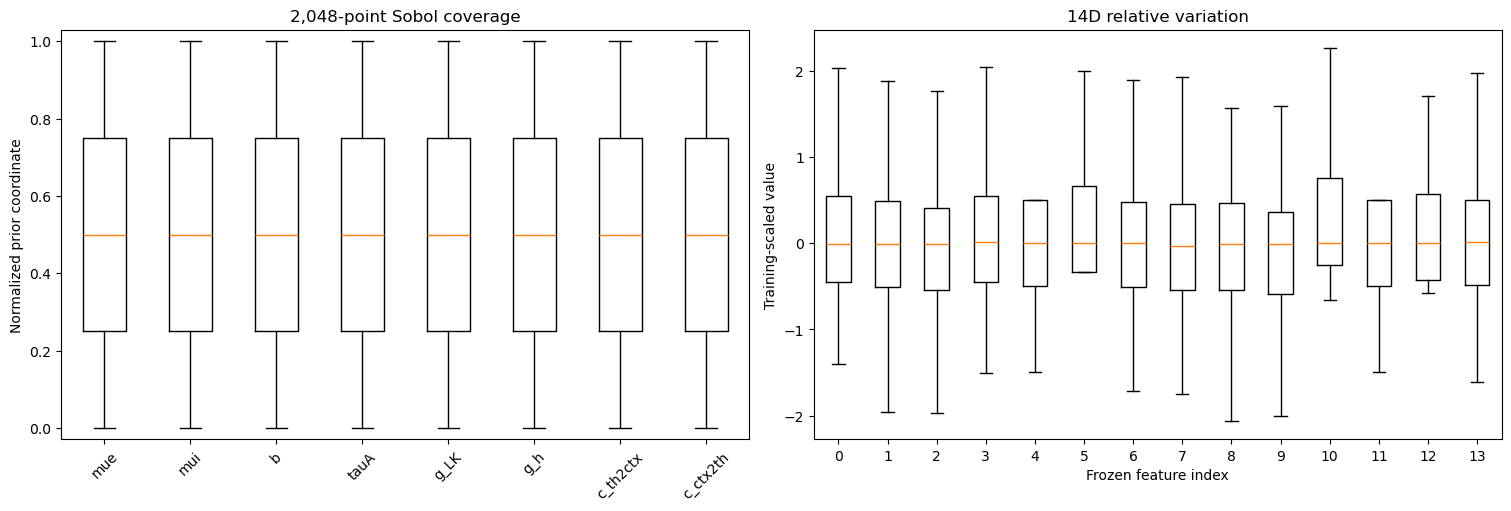

In [4]:
bounds = np.asarray(parameter_contract()["bounds"], dtype=float)
theta_unit = (theta - bounds[:, 0]) / (bounds[:, 1] - bounds[:, 0])
x_scaled = (x - x_location) / x_scale
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
axes[0].boxplot([theta_unit[:, i] for i in range(8)], tick_labels=PARAMETER_NAMES)
axes[0].set(ylabel="Normalized prior coordinate", title="2,048-point Sobol coverage", ylim=(-.03, 1.03))
axes[0].tick_params(axis="x", rotation=45)
axes[1].boxplot([x_scaled[:, i] for i in range(14)], tick_labels=range(14), showfliers=False)
axes[1].set(xlabel="Frozen feature index", ylabel="Training-scaled value", title="14D relative variation")
fig.savefig(FIGURE_DIR / "bank_prior_and_feature_coverage.png", dpi=180)
fig.savefig(FIGURE_DIR / "bank_prior_and_feature_coverage.svg")
plt.show()

## 4. Runtime and failure audit

Green points are successful simulations; failed rows would remain red with NaN
features and explicit reasons. No parameter region is removed post hoc.

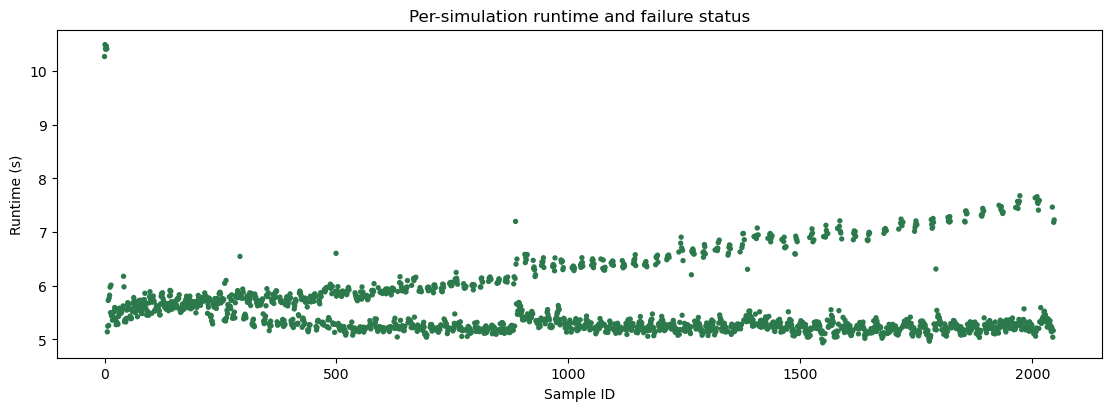

,,rows,runtime_s
split,success,,
train,True,1638,9142.435212
validation,True,410,2304.376446


In [5]:
status = pd.read_csv(OUTPUT_DIR / "bank_status.csv")
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ax.scatter(status.sample_id, status.runtime_s, c=np.where(status.success, "#2c7a4b", "#b23a48"), s=8)
ax.set(xlabel="Sample ID", ylabel="Runtime (s)", title="Per-simulation runtime and failure status")
fig.savefig(FIGURE_DIR / "bank_runtime_failure.png", dpi=180)
fig.savefig(FIGURE_DIR / "bank_runtime_failure.svg")
plt.show()
display(status.groupby(["split", "success"]).agg(rows=("sample_id", "count"), runtime_s=("runtime_s", "sum")))

## 5. Higher-resolution global-collision audit

The Stage-11 same-theta seed-noise floor remains frozen. Theta distance uses
prior-width scaling and x distance uses only training-split scaling. A large
collision fraction warns that multiple far theta values can be observationally
indistinguishable at the measured seed noise level, even though local
Jacobians were rank 8.

,valid_rows,pair_count,noise_floor_from_stage11,far_pair_count,collision_count,near_collision_count,collision_fraction_of_far_pairs,stage11_collision_count,scaling_source
0,2048,2096128,2.304823,1999861,327248,939831,0.163635,1469,training split only


,sample_id_a,sample_id_b,theta_rms_distance,x_distance,x_to_noise_ratio,delta_mue_prior_width,delta_mui_prior_width,delta_b_prior_width,delta_tauA_prior_width,delta_g_LK_prior_width,delta_g_h_prior_width,delta_c_th2ctx_prior_width,delta_c_ctx2th_prior_width
170385,629,1767,0.420104,0.169245,0.073431,0.482183,0.011209,-0.001897,0.663495,0.570502,0.035549,0.115817,-0.631579
186265,708,2036,0.295740,0.177204,0.076884,-0.086349,0.008534,-0.071183,-0.075947,-0.103801,0.553537,0.097576,0.595512
157913,582,1874,0.269955,0.188058,0.081593,0.298780,0.011752,0.021957,0.280487,0.366676,-0.050255,0.444828,-0.282121
90721,311,365,0.302959,0.219813,0.095371,-0.317197,0.019108,-0.093819,-0.397444,-0.248638,0.068778,0.055739,-0.629979
88398,302,532,0.415703,0.231039,0.100241,0.529613,0.026172,0.064075,0.576549,-0.622800,-0.028049,-0.568720,0.229503
82437,277,1745,0.331692,0.249723,0.108348,-0.216493,0.054174,-0.059684,-0.105917,0.049256,0.819560,0.315682,-0.204481
312266,1604,1916,0.341628,0.277680,0.120478,-0.149578,-0.083021,-0.183072,-0.047056,0.100944,-0.087257,0.322339,-0.864278
300639,1460,1854,0.556381,0.279669,0.121341,-0.670578,0.024397,-0.035658,-0.646229,-0.598303,0.698392,-0.269092,0.830179
212038,831,1755,0.341218,0.286144,0.124150,-0.243994,-0.024049,0.158303,-0.531508,0.284958,-0.437265,0.307860,-0.443379
244771,1026,1412,0.380342,0.288395,0.125127,0.332729,-0.022968,-0.027935,0.569965,0.576521,-0.110485,0.594087,0.151266


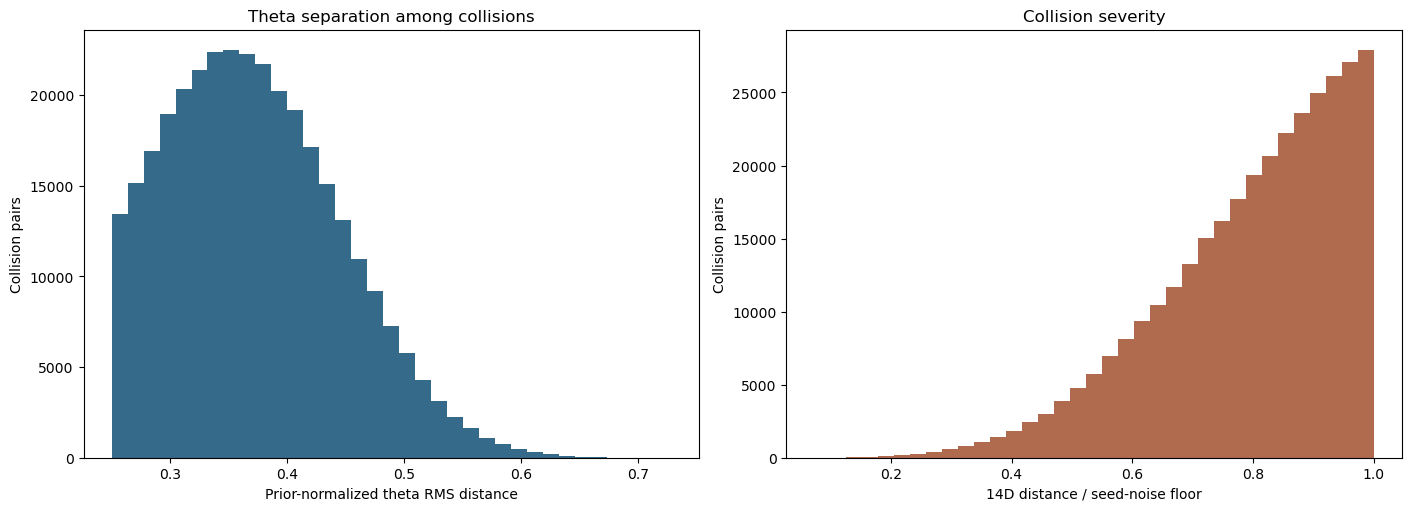

In [6]:
collision = analyze_training_bank_collisions(bank_run["bank_path"], bank_run["split_path"])
collision_summary = collision["summary"]
collision_table = collision["collisions"]
display(pd.DataFrame([collision_summary]))
display(collision_table.head(25))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
axes[0].hist(collision_table["theta_rms_distance"], bins=35, color="#356a8a")
axes[0].set(xlabel="Prior-normalized theta RMS distance", ylabel="Collision pairs", title="Theta separation among collisions")
axes[1].hist(collision_table["x_to_noise_ratio"], bins=35, color="#b06b4f")
axes[1].set(xlabel="14D distance / seed-noise floor", ylabel="Collision pairs", title="Collision severity")
fig.savefig(FIGURE_DIR / "bank_collision_distributions.png", dpi=180)
fig.savefig(FIGURE_DIR / "bank_collision_distributions.svg")
plt.show()

## 6. Training gate

The engineering gate passes because all 2,048 vectors are finite and failure
rate is zero. The high collision burden is a preregistered scientific warning,
not a reason to alter features after seeing results. It must be resolved by
held-out recovery, coverage, SBC, posterior ridge checks, and PPC.

In [7]:
training_gate = {
    "failure_rate_threshold": 0.01,
    "observed_failure_rate": manifest["failure_rate"],
    "schema_order_match": True,
    "fully_finite": bool(np.isfinite(x).all()),
    "training_rows": len(train_idx),
    "validation_rows": len(validation_idx),
    "scaling_fit_on_training_only": True,
    "collision_fraction_of_far_pairs": collision_summary["collision_fraction_of_far_pairs"],
    "pass": bool(manifest["failure_rate"] <= .01 and np.isfinite(x).all()),
    "scientific_identifiability_established": False,
}
(OUTPUT_DIR / "notebook12_validation.json").write_text(json.dumps(training_gate, indent=2), encoding="utf-8")
display(pd.DataFrame([training_gate]))
assert training_gate["pass"]

,failure_rate_threshold,observed_failure_rate,schema_order_match,fully_finite,training_rows,validation_rows,scaling_fit_on_training_only,collision_fraction_of_far_pairs,pass,scientific_identifiability_established
0,0.01,0.0,True,True,1638,410,True,0.163635,True,False


## Conclusion

The 2,048-point bank is technically valid for the authorized exploratory
single-round NPE training: 2,048/2,048 rows are finite, the split and scaling
are frozen, and artifacts are portable. It is not evidence that all eight
parameters are identifiable. Approximately the reported fraction of far-theta
pairs fall inside the empirical seed-noise floor, so false posterior
contraction is a primary held-out failure mode.